In [40]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random

# Set up matplotlib for larger inline display
plt.rcParams['figure.figsize'] = (12, 6)

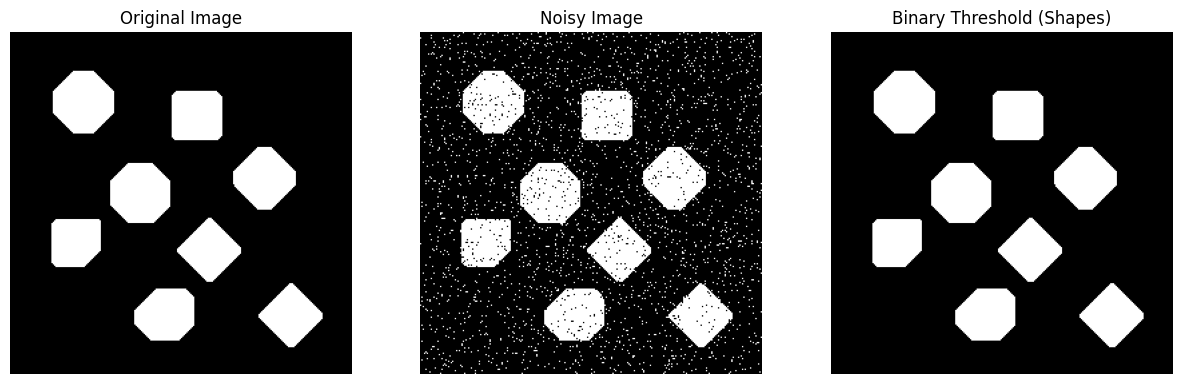

In [41]:
# 1. Read the image using OpenCV (grayscale)
# Make sure 'cameraman.png' is in your working directory!
img_path = '4.png'
original_img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

if original_img is None:
    # Fallback to a synthetic image if cameraman.png is missing just in case
    print("cameraman.png not found! Generating a fallback synthetic image with irregular shapes.")
    original_img = np.zeros((256, 256), dtype=np.uint8)
    original_img[30:100, 30:80] = 255
    original_img[150:220, 160:240] = 255
    original_img[50:80, 180:210] = 255

# # 2. Add Salt and Pepper Noise
# def add_salt_and_pepper_noise(img, prob=0.05):
#     noisy = np.copy(img)
#     rows, cols = noisy.shape
#     for i in range(rows):
#         for j in range(cols):
#             rand = random.random()
#             if rand < prob / 2:
#                 noisy[i, j] = 0     # Pepper
#             elif rand < prob:
#                 noisy[i, j] = 255   # Salt
#     return noisy

# noisy_img = add_salt_and_pepper_noise(original_img, prob=0.08)

# 3. Basic Binary Thresholding (from scratch)
# Cameraman is a dark foreground on a mixed background, let's threshold to get shapes
threshold_value = 100
binary_img = (original_img > threshold_value).astype(np.uint8) * 255

# Display
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].imshow(original_img, cmap='gray')
axs[0].set_title('Original Image')
axs[0].axis('off')

axs[1].imshow(noisy_img, cmap='gray')
axs[1].set_title('Noisy Image')
axs[1].axis('off')

axs[2].imshow(binary_img, cmap='gray')
axs[2].set_title('Binary Threshold (Shapes)')
axs[2].axis('off')
plt.show()

Our Morphological Kernel:
 [[1 1 1]
 [1 1 1]
 [1 1 1]]


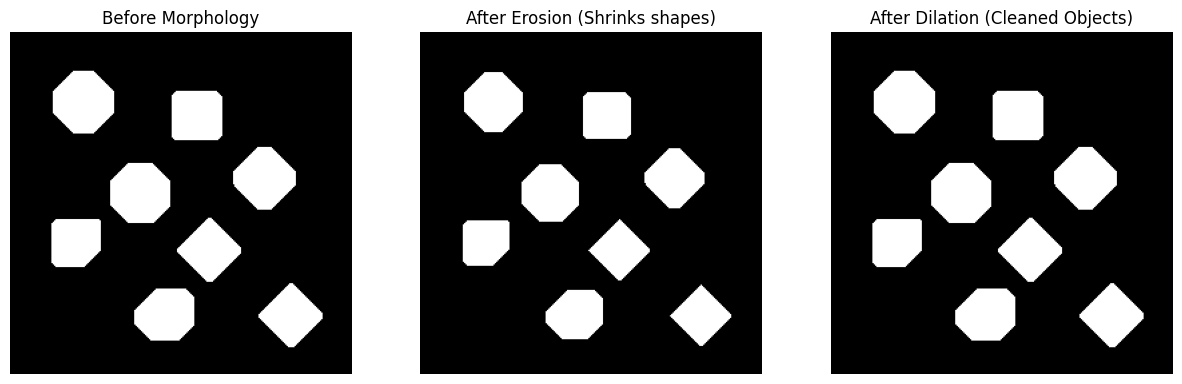

In [42]:
# Define a 3x3 structuring element (Kernel)
kernel = np.array([
    [1, 1, 1],
    [1, 1, 1],
    [1, 1, 1]
], dtype=np.uint8)

print("Our Morphological Kernel:\n", kernel)

def apply_morphology(img, kernel, operation='erosion'):
    h, w = img.shape
    k_h, k_w = kernel.shape
    pad_h, pad_w = k_h // 2, k_w // 2
    
    # Pad image to handle borders
    padded_img = np.pad(img, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant', constant_values=0)
    output_img = np.zeros_like(img)
    
    for i in range(h):
        for j in range(w):
            region = padded_img[i:i+k_h, j:j+k_w]
            if operation == 'erosion':
                # If all kernel 1s match the region, keep it 255, else 0
                if np.min(region[kernel == 1]) == 255:
                    output_img[i, j] = 255
            elif operation == 'dilation':
                # If any kernel 1 matches a 255 in the region, make it 255
                if np.max(region[kernel == 1]) == 255:
                    output_img[i, j] = 255
                    
    return output_img

# Apply Opening: Erosion -> Dilation to remove noise blobs
eroded_img = apply_morphology(binary_img, kernel, 'erosion')
cleaned_img = apply_morphology(eroded_img, kernel, 'dilation')

# Display intermediate steps
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].imshow(binary_img, cmap='gray')
axs[0].set_title('Before Morphology')
axs[0].axis('off')

axs[1].imshow(eroded_img, cmap='gray')
axs[1].set_title('After Erosion (Shrinks shapes)')
axs[1].axis('off')

axs[2].imshow(cleaned_img, cmap='gray')
axs[2].set_title('After Dilation (Cleaned Objects)')
axs[2].axis('off')
plt.show()

In [43]:
def find_objects(binary_img):
    h, w = binary_img.shape
    visited = np.zeros_like(binary_img, dtype=bool)
    objects = []
    
    # Directions for 8-connectivity
    directions = [(-1,-1), (-1,0), (-1,1), (0,-1), (0,1), (1,-1), (1,0), (1,1)]
    
    for i in range(h):
        for j in range(w):
            if binary_img[i, j] == 255 and not visited[i, j]:
                # Found a new object, start BFS
                queue = [(i, j)]
                visited[i, j] = True
                current_object_points = []
                
                while queue:
                    r, c = queue.pop(0)
                    current_object_points.append((c, r)) # Store as (x, y)
                    
                    for dr, dc in directions:
                        nr, nc = r + dr, c + dc
                        if 0 <= nr < h and 0 <= nc < w:
                            if binary_img[nr, nc] == 255 and not visited[nr, nc]:
                                visited[nr, nc] = True
                                queue.append((nr, nc))
                
                # Only keep objects larger than a certain pixel count to avoid tiny artifacts
                if len(current_object_points) > 100: 
                    objects.append(current_object_points)
                    
    return objects

objects = find_objects(cleaned_img)
print(f"Found {len(objects)} distinct objects.")

Found 8 distinct objects.


In [44]:
def cross_product(o, a, b):
    # Returns positive if a->b is a counter-clockwise turn from o->a
    return (a[0] - o[0]) * (b[1] - o[1]) - (a[1] - o[1]) * (b[0] - o[0])

def get_convex_hull(points):
    # Sort points lexicographically
    points = sorted(points)
    
    if len(points) <= 3:
        return points
    
    # Build lower hull
    lower = []
    for p in points:
        while len(lower) >= 2 and cross_product(lower[-2], lower[-1], p) <= 0:
            lower.pop()
        lower.append(p)
        
    # Build upper hull
    upper = []
    for p in reversed(points):
        while len(upper) >= 2 and cross_product(upper[-2], upper[-1], p) <= 0:
            upper.pop()
        upper.append(p)
        
    # Concatenate lower and upper hull, dropping the last point of each 
    # (because it's the same as the first point of the other)
    return lower[:-1] + upper[:-1]

# Calculate hulls for each object
object_hulls = []
for obj in objects:
    hull = get_convex_hull(obj)
    object_hulls.append(hull)

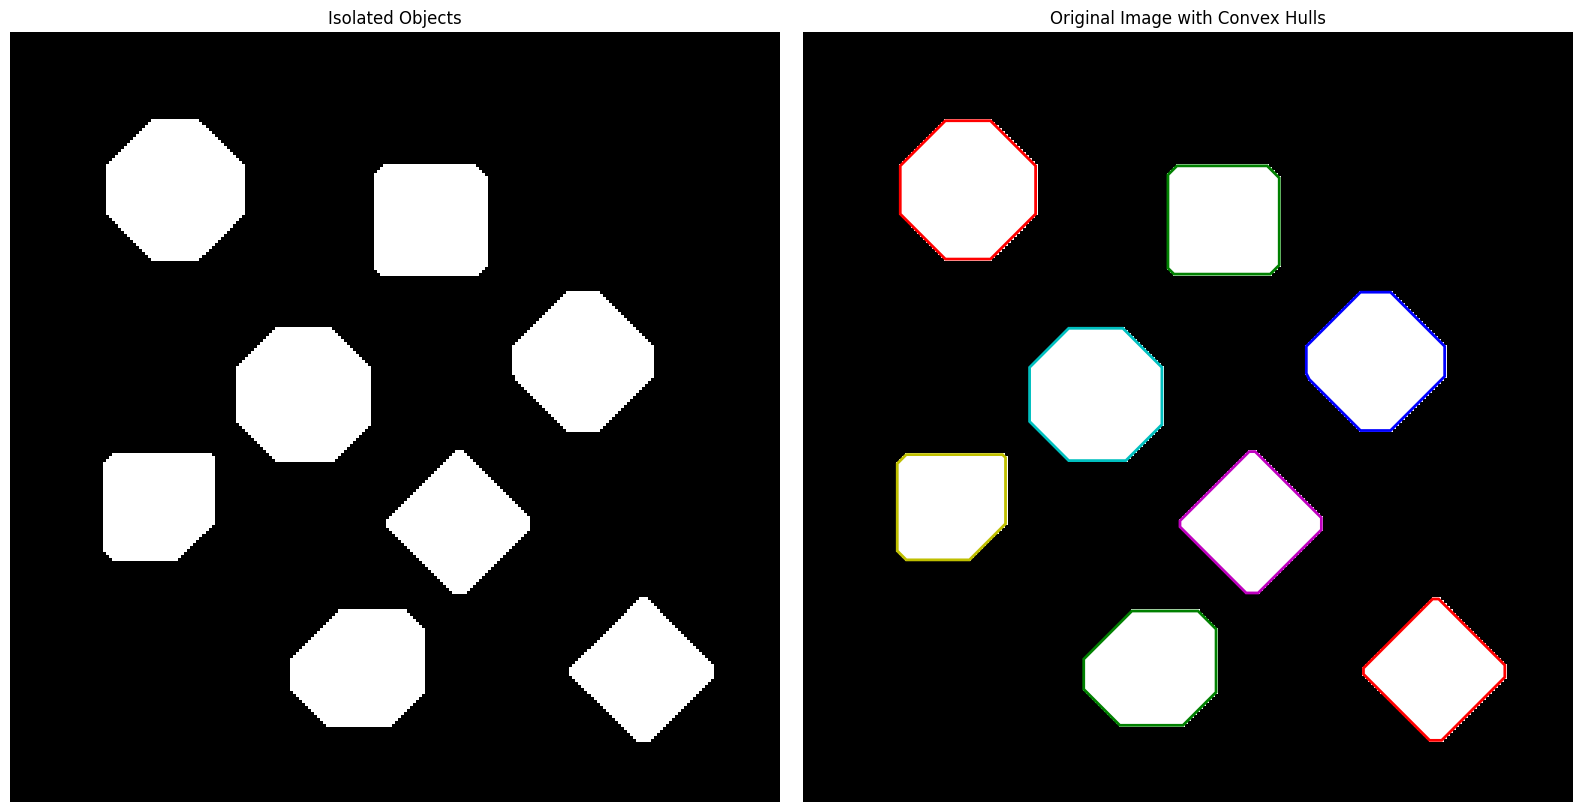

In [45]:
from matplotlib.patches import Polygon

fig, ax = plt.subplots(1, 2, figsize=(16, 8))

# Plot 1: The cleaned binary shapes
ax[0].imshow(cleaned_img, cmap='gray')
ax[0].set_title('Isolated Objects')
ax[0].axis('off')

# Plot 2: Original image with Convex Hulls drawn over it
ax[1].imshow(original_img, cmap='gray')
ax[1].set_title('Original Image with Convex Hulls')
ax[1].axis('off')

# Draw the hulls
colors = ['r', 'g', 'b', 'c', 'm', 'y']
for idx, hull in enumerate(object_hulls):
    # Matplotlib Polygons expect a list of (x, y) coordinates
    poly = Polygon(hull, closed=True, fill=False, edgecolor=colors[idx % len(colors)], linewidth=2)
    ax[1].add_patch(poly)

plt.tight_layout()
plt.show()

# Optional: Save the final image using OpenCV (requires converting canvas to image format, 
# but usually saving the Matplotlib figure is easier here).
# cv2.imwrite('output_hull.png', cleaned_img)